# What Drives Final Grades in Secondary School Portuguese?
### STDS 36103 – Assessment Task 2: Data Analysis Project (code appendix)

**Dataset:** Student Performance Data Set – Portuguese course (`student-por.csv`, 649 students, 33 variables).
Source: Cortez & Silva (2008), UCI Machine Learning Repository; Kaggle mirror by *Data-Science Sean* (CC0).

**Research questions**
1. **RQ1** – Which background and behaviour factors (known at the start of the year) are associated with the final grade `G3`, and how much of the variation do they explain? *(multiple linear regression)*
2. **RQ2** – Can the same factors identify students at risk of **failing** (`G3 < 10`)? *(logistic regression)*
3. **RQ3** – How much does the first-period grade `G1` improve prediction compared with background factors alone? *(nested linear regression)*

The notebook is self-contained: it runs top-to-bottom and saves every figure used in the report and slides to `figures/`.

## 0. Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, mean_absolute_error

warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
RNG = 42

# Consistent, non-default figure style
NAVY, TEAL, CORAL, SAND, GREY = "#1B2A41", "#2A9D8F", "#E76F51", "#E9C46A", "#8D99AE"
sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "axes.titleweight": "bold",
                     "axes.titlesize": 13, "axes.labelsize": 11, "axes.spines.top": False,
                     "axes.spines.right": False})
def save(fig, name):
    fig.tight_layout(); fig.savefig(f"figures/{name}.png", bbox_inches="tight"); plt.show()

## 1. Data loading and quality checks

In [2]:
df = pd.read_csv("student-por.csv")
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.head()

Shape: (649, 33)
Missing values: 0
Duplicate rows: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
# Check value ranges against the data dictionary (ordinal scales 1-5, grades 0-20, etc.)
ranges = {"age": (15, 22), "Medu": (0, 4), "Fedu": (0, 4), "traveltime": (1, 4), "studytime": (1, 4),
          "failures": (0, 3), "famrel": (1, 5), "freetime": (1, 5), "goout": (1, 5), "Dalc": (1, 5),
          "Walc": (1, 5), "health": (1, 5), "absences": (0, 93), "G1": (0, 20), "G2": (0, 20), "G3": (0, 20)}
bad = {c: int(((df[c] < lo) | (df[c] > hi)).sum()) for c, (lo, hi) in ranges.items()}
print("Out-of-range values per column:", bad)
df.describe().T.round(2)

Out-of-range values per column: {'age': 0, 'Medu': 0, 'Fedu': 0, 'traveltime': 0, 'studytime': 0, 'failures': 0, 'famrel': 0, 'freetime': 0, 'goout': 0, 'Dalc': 0, 'Walc': 0, 'health': 0, 'absences': 0, 'G1': 0, 'G2': 0, 'G3': 0}


,count,mean,std,min,25%,50%,75%,max
age,649.0,16.74,1.22,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.51,1.13,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.31,1.10,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.57,0.75,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.93,0.83,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.22,0.59,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.93,0.96,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.18,1.05,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.18,1.18,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.50,0.92,1.0,1.0,1.0,2.0,5.0


### 1.1 The 'G3 = 0' issue
A final grade of exactly 0 is suspicious: these students had non-zero `G1`, zero absences, and most also have `G2 = 0`.
This pattern suggests they **did not sit the final exam / dropped out** rather than scoring zero. Keeping them would
distort a model of *achievement* (they are extreme low outliers unrelated to learning). Decision:
* **Linear models (RQ1, RQ3):** exclude the 15 `G3 = 0` records (n = 634).
* **Logistic model (RQ2):** keep them and count them as *fail*, because not completing is a failure outcome that a school wants to flag.

In [4]:
zero = df[df.G3 == 0]
print("Students with G3 = 0:", len(zero), f"({len(zero)/len(df):.1%})")
print("Of these, G2 = 0:", int((zero.G2 == 0).sum()), "| absences = 0:", int((zero.absences == 0).sum()))
zero[["school", "sex", "age", "failures", "absences", "G1", "G2", "G3"]]

Students with G3 = 0: 15 (2.3%)
Of these, G2 = 0: 7 | absences = 0: 15


,school,sex,age,failures,absences,G1,G2,G3
163,GP,M,18,2,0,11,9,0
440,MS,M,16,0,0,7,0,0
519,MS,M,16,0,0,8,7,0
563,MS,M,17,1,0,7,0,0
567,MS,M,18,1,0,4,0,0
583,MS,F,18,1,0,8,6,0
586,MS,F,17,0,0,8,8,0
597,MS,F,18,1,0,9,0,0
603,MS,F,18,0,0,5,0,0
605,MS,F,19,1,0,5,0,0


In [5]:
# Clean / feature preparation
df["fail"] = (df.G3 < 10).astype(int)          # Portuguese pass mark is 10/20
df_lin = df[df.G3 > 0].copy()                    # sample for linear models
print("Linear-model sample:", len(df_lin), "| Overall fail rate:", f"{df.fail.mean():.1%}")

Linear-model sample: 634 | Overall fail rate: 15.4%


## 2. Exploratory data analysis

### 2.1 Distribution of the final grade

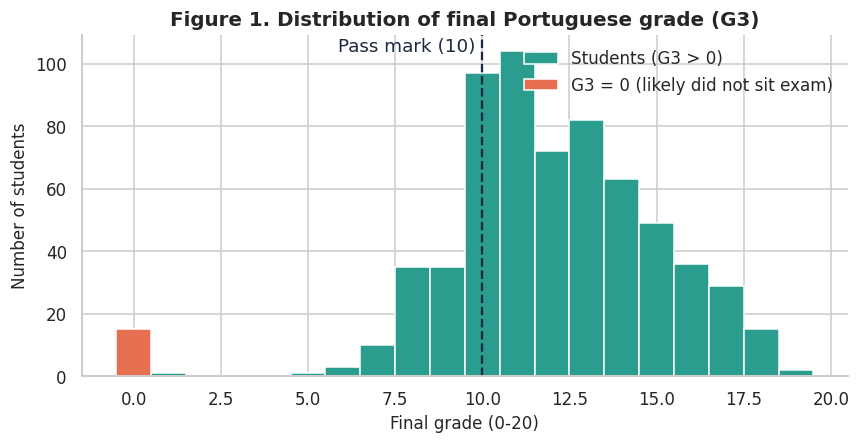

count    634.00
mean      12.19
std        2.69
min        1.00
25%       10.00
50%       12.00
75%       14.00
max       19.00
Name: G3, dtype: float64
Skewness: 0.125


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.arange(-0.5, 20.5, 1)
ax.hist(df_lin.G3, bins=bins, color=TEAL, edgecolor="white", label="Students (G3 > 0)")
ax.hist(df.G3[df.G3 == 0], bins=bins, color=CORAL, edgecolor="white", label="G3 = 0 (likely did not sit exam)")
ax.axvline(10, color=NAVY, ls="--", lw=1.5); ax.text(9.8, ax.get_ylim()[1]*0.95, "Pass mark (10)", color=NAVY, ha="right")
ax.set(title="Figure 1. Distribution of final Portuguese grade (G3)", xlabel="Final grade (0-20)", ylabel="Number of students")
ax.legend(frameon=False, loc="upper right"); save(fig, "fig1_g3_distribution")
print(df_lin.G3.describe().round(2)); print("Skewness:", round(stats.skew(df_lin.G3), 3))

### 2.2 Correlations between numeric variables and G3

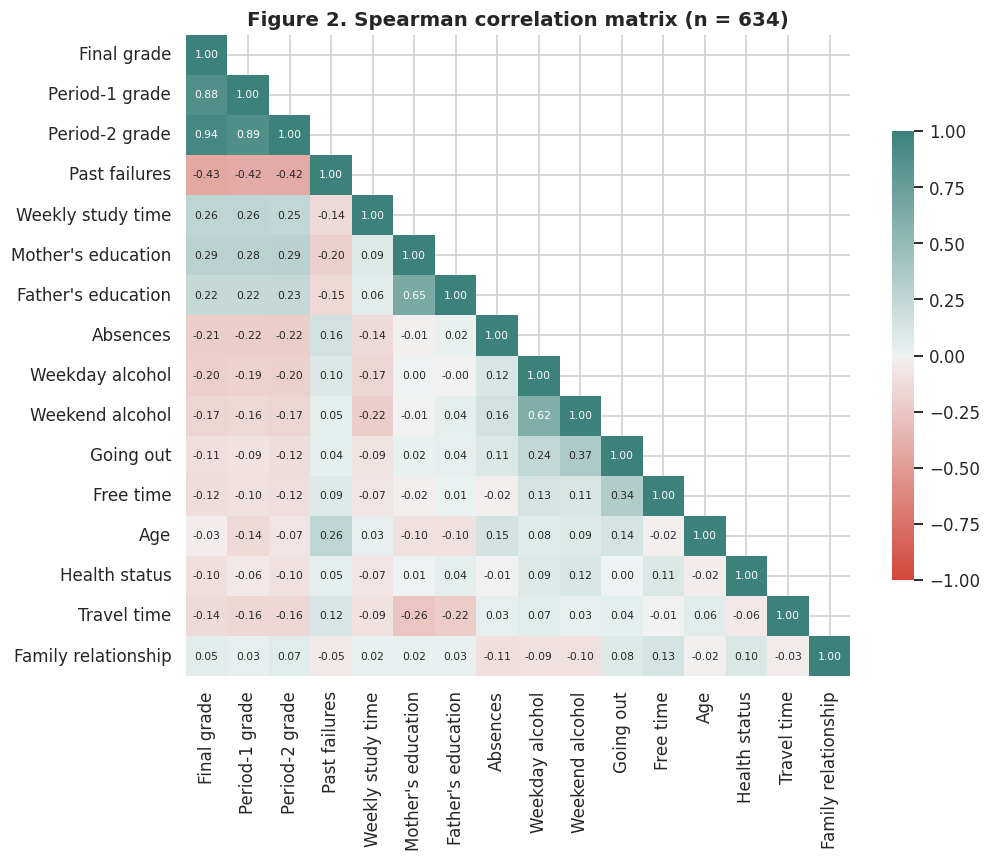

failures     -0.431
absences     -0.214
Dalc         -0.204
Walc         -0.166
traveltime   -0.136
freetime     -0.123
goout        -0.114
health       -0.103
age          -0.030
famrel        0.055
Fedu          0.220
studytime     0.264
Medu          0.289
G1            0.879
G2            0.941
Name: G3, dtype: float64

In [7]:
num = ["G3", "G1", "G2", "failures", "studytime", "Medu", "Fedu", "absences", "Dalc", "Walc", "goout",
       "freetime", "age", "health", "traveltime", "famrel"]
labels = {"G3": "Final grade", "G1": "Period-1 grade", "G2": "Period-2 grade", "failures": "Past failures",
          "studytime": "Weekly study time", "Medu": "Mother's education", "Fedu": "Father's education",
          "absences": "Absences", "Dalc": "Weekday alcohol", "Walc": "Weekend alcohol", "goout": "Going out",
          "freetime": "Free time", "age": "Age", "health": "Health status", "traveltime": "Travel time",
          "famrel": "Family relationship"}
corr = df_lin[num].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9.5, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr.rename(index=labels, columns=labels), mask=mask, cmap=sns.diverging_palette(15, 180, as_cmap=True),
            center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7}, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Figure 2. Spearman correlation matrix (n = 634)"); save(fig, "fig2_correlation")
corr["G3"].drop("G3").sort_values().round(3)

**Notes for modelling**
* `G1` and `G2` correlate > 0.85 with `G3` – they are almost the same outcome measured earlier. Including them would hide
  every other factor, so they are left out of RQ1/RQ2 and studied separately in RQ3.
* `Medu`–`Fedu` (ρ ≈ 0.6) and `Dalc`–`Walc` (ρ ≈ 0.6) are correlated pairs → keep one of each (`Medu`, `Dalc`) to limit multicollinearity.
* `failures` has the strongest negative association of the background variables.

### 2.3 Key categorical and ordinal factors

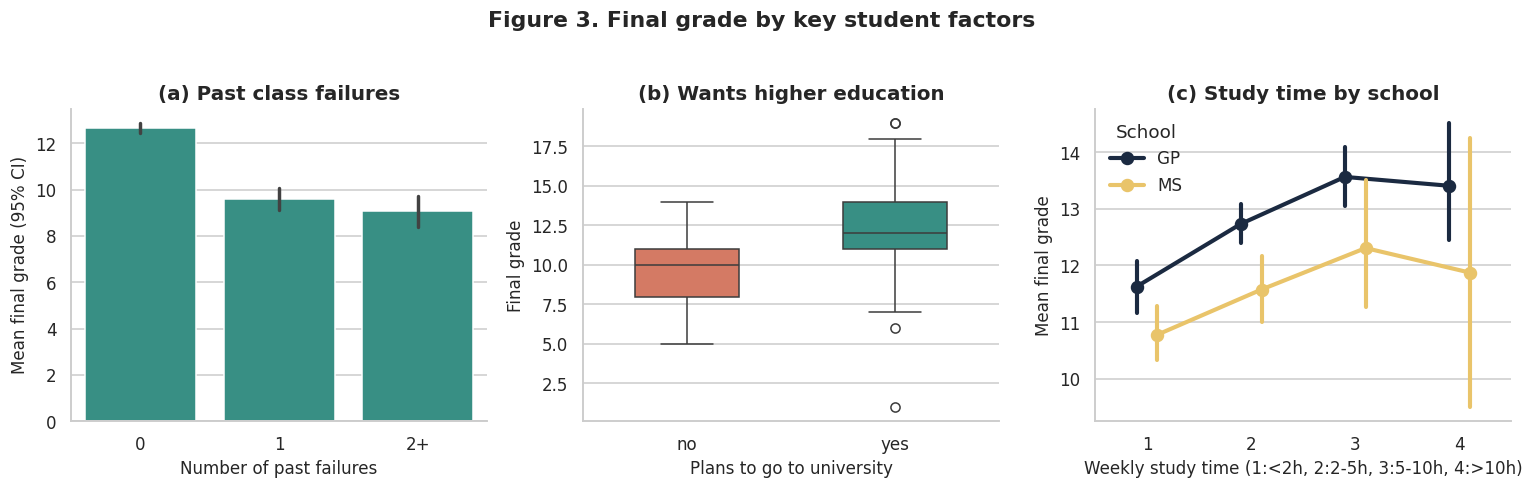

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
# (a) failures
g = df_lin.assign(failures_c=df_lin.failures.clip(upper=2).map({0: "0", 1: "1", 2: "2+"}))
sns.barplot(data=g, x="failures_c", y="G3", order=["0", "1", "2+"], color=TEAL, errorbar=("ci", 95), ax=axes[0])
axes[0].set(title="(a) Past class failures", xlabel="Number of past failures", ylabel="Mean final grade (95% CI)")
# (b) higher education
sns.boxplot(data=df_lin, x="higher", y="G3", order=["no", "yes"], palette=[CORAL, TEAL], ax=axes[1], width=.5)
axes[1].set(title="(b) Wants higher education", xlabel="Plans to go to university", ylabel="Final grade")
# (c) school x study time
sns.pointplot(data=df_lin, x="studytime", y="G3", hue="school", palette=[NAVY, SAND], errorbar=("ci", 95), dodge=.2, ax=axes[2])
axes[2].set(title="(c) Study time by school", xlabel="Weekly study time (1:<2h, 2:2-5h, 3:5-10h, 4:>10h)", ylabel="Mean final grade")
axes[2].legend(title="School", labels=None, frameon=False)
fig.suptitle("Figure 3. Final grade by key student factors", fontweight="bold", y=1.03); save(fig, "fig3_key_factors")

In [9]:
# Group summaries and quick significance tests (non-parametric because G3 is discrete/bounded)
for col in ["failures", "higher", "school", "studytime", "schoolsup", "sex", "Dalc"]:
    s = df_lin.groupby(col).G3.agg(["count", "mean", "median"]).round(2)
    groups = [grp.G3.values for _, grp in df_lin.groupby(col)]
    p = stats.mannwhitneyu(*groups).pvalue if len(groups) == 2 else stats.kruskal(*groups).pvalue
    print(f"--- {col}  (test p = {p:.2g})"); print(s, "\n")

--- failures  (test p = 2.3e-25)
          count   mean  median
failures                      
0           543  12.65    12.0
1            63   9.60    10.0
2            15   9.40    10.0
3            13   8.69     9.0 

--- higher  (test p = 2.5e-18)
        count   mean  median
higher                      
no         64   9.48    10.0
yes       570  12.49    12.0 

--- school  (test p = 3.4e-10)
        count   mean  median
school                      
GP        422  12.61    13.0
MS        212  11.35    11.0 

--- studytime  (test p = 7e-10)
           count   mean  median
studytime                      
1            204  11.27    11.0
2            298  12.38    12.0
3             97  13.23    13.0
4             35  13.06    13.0 

--- schoolsup  (test p = 0.015)
           count   mean  median
schoolsup                      
no           567  12.28    12.0
yes           67  11.45    11.0 

--- sex  (test p = 0.001)
     count   mean  median
sex                      
F      376  12.

In [10]:
# Fail rate by factor (for RQ2 and the slides)
fr = pd.concat({c: df.groupby(c).fail.mean() for c in ["failures", "higher", "school"]}).rename("fail_rate")
print((fr * 100).round(1))

failures  0       9.3
          1      45.7
          2      50.0
          3      64.3
higher    no     47.8
          yes    11.6
school    GP      7.6
          MS     30.1
Name: fail_rate, dtype: float64


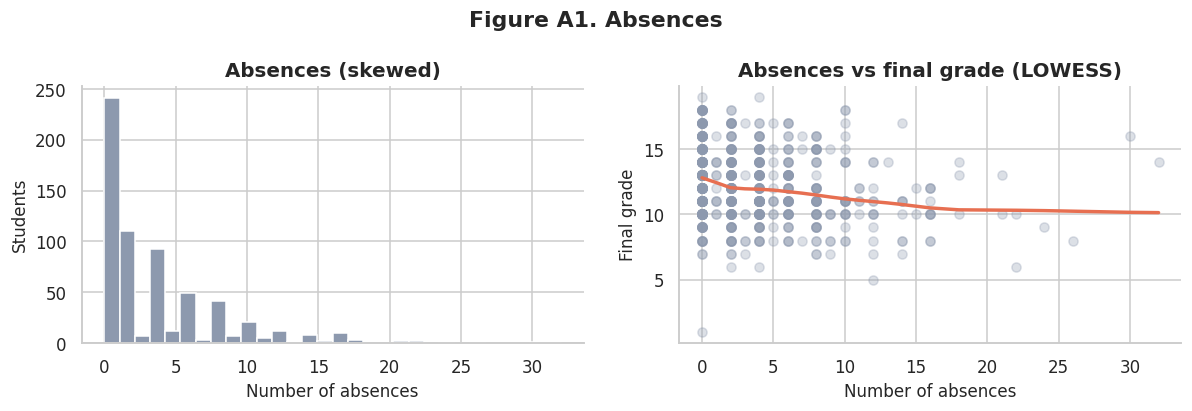

Absences skewness: 1.99


In [11]:
# Absences: heavily right-skewed count
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(df_lin.absences, bins=30, color=GREY, edgecolor="white"); ax[0].set(title="Absences (skewed)", xlabel="Number of absences", ylabel="Students")
sns.regplot(data=df_lin, x="absences", y="G3", lowess=True, scatter_kws={"alpha": .3, "color": GREY}, line_kws={"color": CORAL}, ax=ax[1])
ax[1].set(title="Absences vs final grade (LOWESS)", xlabel="Number of absences", ylabel="Final grade")
fig.suptitle("Figure A1. Absences", fontweight="bold"); save(fig, "figA1_absences")
print("Absences skewness:", round(stats.skew(df_lin.absences), 2))

## 3. RQ1 – Multiple linear regression (background factors → G3)

**Model:** Ordinary Least Squares
`G3 ~ failures + higher + school + studytime + Medu + absences + Dalc + schoolsup + sex + age + goout + health`

**Feature choice** follows the EDA (variables with a clear bivariate association) and the original study (Cortez & Silva, 2008),
dropping one variable from each highly correlated pair and excluding `G1`/`G2` (data leakage for an early-warning purpose).

In [12]:
formula1 = ("G3 ~ failures + C(higher, Treatment('no')) + C(school) + studytime + Medu + absences + Dalc"
            " + C(schoolsup) + C(sex) + age + goout + health")
m1_ols = smf.ols(formula1, data=df_lin).fit()
print(m1_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     28.52
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           9.38e-52
Time:                        10:26:40   Log-Likelihood:                -1387.7
No. Observations:                 634   AIC:                             2801.
Df Residuals:                     621   BIC:                             2859.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### 3.1 Assumption checks

In [13]:
res, fit = m1_ols.resid, m1_ols.fittedvalues
bp = het_breuschpagan(res, m1_ols.model.exog)
sw = stats.shapiro(res)
print(f"Breusch-Pagan LM = {bp[0]:.2f}, p = {bp[1]:.4f}   (H0: constant variance)")
print(f"Shapiro-Wilk W = {sw.statistic:.3f}, p = {sw.pvalue:.4f}   (H0: normal residuals)")
print(f"Residual skew = {stats.skew(res):.3f}, excess kurtosis = {stats.kurtosis(res):.3f}")
print(f"Durbin-Watson = {durbin_watson(res):.3f}")

X = pd.DataFrame(m1_ols.model.exog, columns=m1_ols.model.exog_names).drop(columns="Intercept")
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns).round(2)
print("\nVariance inflation factors:\n", vif.sort_values(ascending=False))

infl = m1_ols.get_influence(); cooks = infl.cooks_distance[0]
print("\nMax Cook's distance:", round(cooks.max(), 3), "| points > 4/n:", int((cooks > 4/len(df_lin)).sum()))

Breusch-Pagan LM = 20.37, p = 0.0605   (H0: constant variance)
Shapiro-Wilk W = 0.993, p = 0.0031   (H0: normal residuals)
Residual skew = 0.117, excess kurtosis = 0.395
Durbin-Watson = 1.790

Variance inflation factors:
 age                                  1.23
Dalc                                 1.22
C(sex)[T.M]                          1.21
failures                             1.21
C(higher, Treatment('no'))[T.yes]    1.20
C(school)[T.MS]                      1.18
Medu                                 1.15
absences                             1.14
studytime                            1.13
C(schoolsup)[T.yes]                  1.09
goout                                1.09
health                               1.03
dtype: float64

Max Cook's distance: 0.043 | points > 4/n: 32


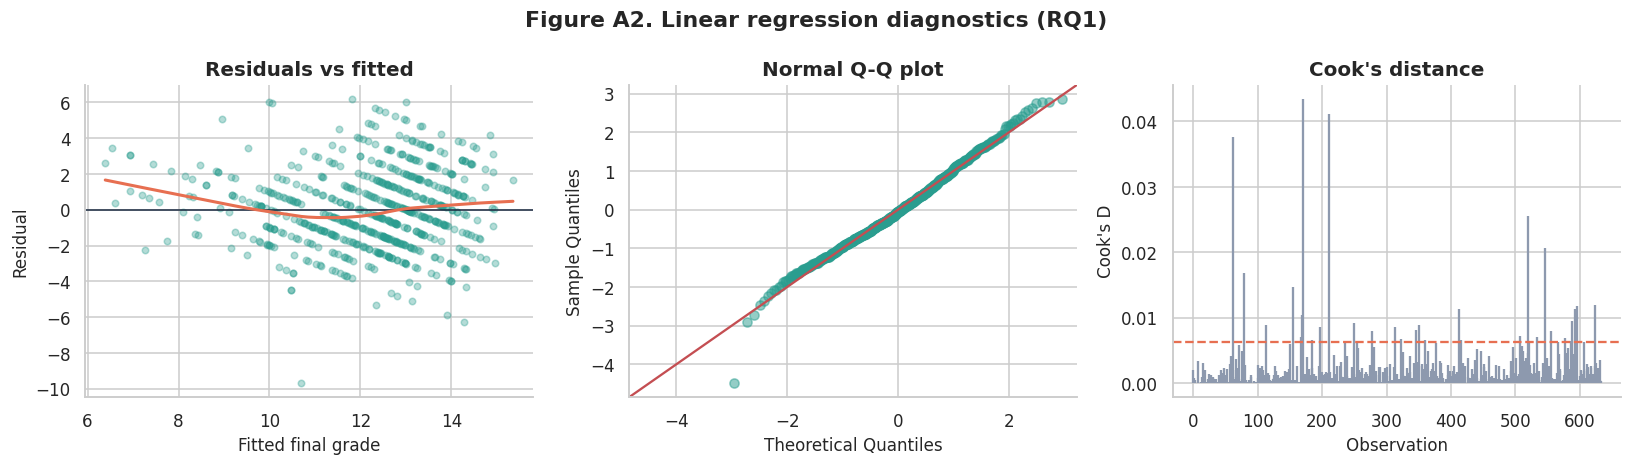

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].scatter(fit, res, alpha=.35, color=TEAL, s=18); ax[0].axhline(0, color=NAVY, lw=1)
sm_low = sm.nonparametric.lowess(res, fit); ax[0].plot(sm_low[:, 0], sm_low[:, 1], color=CORAL, lw=2)
ax[0].set(title="Residuals vs fitted", xlabel="Fitted final grade", ylabel="Residual")
sm.qqplot(res, line="45", fit=True, ax=ax[1], markerfacecolor=TEAL, markeredgecolor=TEAL, alpha=.5); ax[1].set_title("Normal Q-Q plot")
ax[2].stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ", linefmt=GREY); ax[2].axhline(4/len(df_lin), color=CORAL, ls="--")
ax[2].set(title="Cook's distance", xlabel="Observation", ylabel="Cook's D")
fig.suptitle("Figure A2. Linear regression diagnostics (RQ1)", fontweight="bold"); save(fig, "figA2_diagnostics")

**Interpretation of diagnostics**
* **Linearity:** the LOWESS line in the residual plot is close to flat → acceptable.
* **Homoscedasticity:** judged with Breusch-Pagan above. **Mitigation:** we report heteroscedasticity-robust (HC3) standard errors, which remain valid whether or not variance is constant.
* **Normality:** residuals are close to normal in the Q-Q plot (slightly heavy tails because the grade is a bounded integer). With n = 634 the CLT makes coefficient inference robust to this.
* **Multicollinearity:** all VIF values are well below 5.
* **Influence:** no observation has Cook's D near 1; the refit without high-influence points (below) gives similar coefficients.
* **Independence:** students are separate individuals; Durbin-Watson ≈ 2. (Clustering within school is partly handled by the `school` term.)

In [15]:
# Final RQ1 model: same OLS fit, robust HC3 standard errors
m1 = smf.ols(formula1, data=df_lin).fit(cov_type="HC3")
nice = {"Intercept": "Intercept", "failures": "Past failures (per failure)",
        "C(higher, Treatment('no'))[T.yes]": "Wants higher education (yes)", "C(school)[T.MS]": "School MS (vs GP)",
        "studytime": "Study time (per level)", "Medu": "Mother's education (per level)", "absences": "Absences (per day)",
        "Dalc": "Weekday alcohol (per level)", "C(schoolsup)[T.yes]": "Extra school support (yes)", "C(sex)[T.M]": "Male (vs female)",
        "age": "Age (per year)", "goout": "Going out (per level)", "health": "Health status (per level)"}
coef1 = pd.DataFrame({"coef": m1.params, "se_HC3": m1.bse, "ci_low": m1.conf_int()[0], "ci_high": m1.conf_int()[1], "p": m1.pvalues}).rename(index=nice)
print(f"n = {int(m1.nobs)}, R2 = {m1.rsquared:.3f}, adj R2 = {m1.rsquared_adj:.3f}, F-test p = {m1.f_pvalue:.2g}")
coef1.round(3)

n = 634, R2 = 0.355, adj R2 = 0.343, F-test p = 7.1e-55


,coef,se_HC3,ci_low,ci_high,p
Intercept,6.602,1.360,3.936,9.267,0.000
Wants higher education (yes),1.726,0.279,1.178,2.274,0.000
School MS (vs GP),-0.956,0.216,-1.380,-0.532,0.000
Extra school support (yes),-1.152,0.260,-1.661,-0.643,0.000
Male (vs female),-0.443,0.201,-0.837,-0.049,0.028
Past failures (per failure),-1.293,0.161,-1.609,-0.977,0.000
Study time (per level),0.298,0.116,0.070,0.526,0.010
Mother's education (per level),0.369,0.086,0.201,0.537,0.000
Absences (per day),-0.085,0.024,-0.132,-0.037,0.000
Weekday alcohol (per level),-0.240,0.122,-0.478,-0.001,0.049


In [16]:
# Robustness: refit without influential points
keep = cooks <= 4/len(df_lin)
m1_rob = smf.ols(formula1, data=df_lin[keep]).fit(cov_type="HC3")
pd.DataFrame({"all data": m1.params, "without influential": m1_rob.params}).rename(index=nice).round(3)

,all data,without influential
Intercept,6.602,6.777
Wants higher education (yes),1.726,1.490
School MS (vs GP),-0.956,-1.076
Extra school support (yes),-1.152,-1.376
Male (vs female),-0.443,-0.519
Past failures (per failure),-1.293,-1.408
Study time (per level),0.298,0.345
Mother's education (per level),0.369,0.395
Absences (per day),-0.085,-0.107
Weekday alcohol (per level),-0.240,-0.267


In [17]:
# Out-of-sample performance: 10-fold cross-validation
def cv_ols(formula, data, k=10):
    kf = KFold(k, shuffle=True, random_state=RNG); r2, mae = [], []
    for tr, te in kf.split(data):
        m = smf.ols(formula, data=data.iloc[tr]).fit(); p = m.predict(data.iloc[te]); y = data.G3.iloc[te]
        r2.append(1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()); mae.append(mean_absolute_error(y, p))
    return np.mean(r2), np.mean(mae)
cv_r2_1, cv_mae_1 = cv_ols(formula1, df_lin)
print(f"10-fold CV: R2 = {cv_r2_1:.3f}, MAE = {cv_mae_1:.2f} grade points")

10-fold CV: R2 = 0.321, MAE = 1.75 grade points


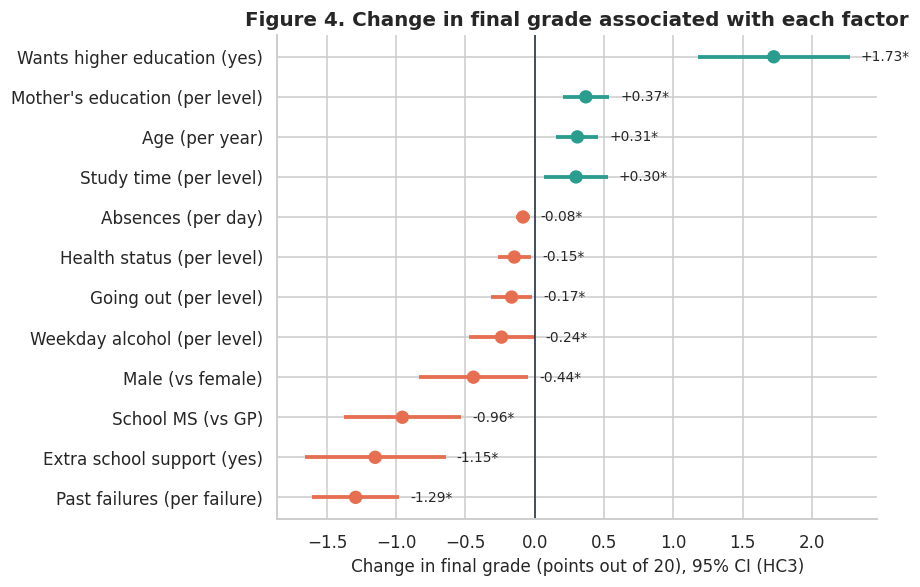

In [18]:
# Coefficient plot (Figure 4)
cp = coef1.drop("Intercept").sort_values("coef")
fig, ax = plt.subplots(figsize=(8.5, 5.5))
colors = [CORAL if c < 0 else TEAL for c in cp.coef]
ax.hlines(cp.index, cp.ci_low, cp.ci_high, color=colors, lw=2.5)
ax.scatter(cp.coef, cp.index, color=colors, s=60, zorder=3)
ax.axvline(0, color=NAVY, lw=1)
for i, (c, p) in enumerate(zip(cp.coef, cp.p)):
    ax.text(cp.ci_high.iloc[i] + .08, i, f"{c:+.2f}{'*' if p < .05 else ''}", va="center", fontsize=9)
ax.set(title="Figure 4. Change in final grade associated with each factor",
       xlabel="Change in final grade (points out of 20), 95% CI (HC3)")
save(fig, "fig4_coefficients")

## 4. RQ2 – Logistic regression: who is at risk of failing?
Outcome: `fail = 1` if `G3 < 10` (includes the 15 non-completers). Same predictors as RQ1 → coefficients reported as **odds ratios**.

In [19]:
formula2 = formula1.replace("G3 ~", "fail ~")
m2 = smf.logit(formula2, data=df).fit(disp=0)
print(m2.summary())
or2 = pd.DataFrame({"OR": np.exp(m2.params), "ci_low": np.exp(m2.conf_int()[0]), "ci_high": np.exp(m2.conf_int()[1]), "p": m2.pvalues}).rename(index=nice)
print(f"n = {int(m2.nobs)}, McFadden pseudo-R2 = {m2.prsquared:.3f}, LR test p = {m2.llr_pvalue:.3g}")
or2.round(3)

                           Logit Regression Results                           
Dep. Variable:                   fail   No. Observations:                  649
Model:                          Logit   Df Residuals:                      636
Method:                           MLE   Df Model:                           12
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                  0.2703
Time:                        10:26:43   Log-Likelihood:                -203.50
converged:                       True   LL-Null:                       -278.89
Covariance Type:            nonrobust   LLR p-value:                 3.914e-26
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.9603      2.107      0.456      0.649      -3.169       5.090
C(higher, Treatment('no'))[T.yes]    -1.3206      0.342     -3

,OR,ci_low,ci_high,p
Intercept,2.612,0.042,162.401,0.649
Wants higher education (yes),0.267,0.137,0.522,0.000
School MS (vs GP),6.988,3.864,12.638,0.000
Extra school support (yes),1.464,0.580,3.691,0.419
Male (vs female),1.392,0.789,2.458,0.254
Past failures (per failure),3.053,2.084,4.473,0.000
Study time (per level),0.790,0.561,1.112,0.176
Mother's education (per level),0.998,0.785,1.268,0.984
Absences (per day),1.070,1.014,1.129,0.013
Weekday alcohol (per level),1.094,0.833,1.436,0.517


In [20]:
# Assumption checks for logistic regression
# 1) Events per variable
print("Fail events:", int(df.fail.sum()), "| predictors:", len(m2.params) - 1, "| EPV =", round(df.fail.sum() / (len(m2.params) - 1), 1))
# 2) Linearity of the logit for continuous predictors (Box-Tidwell style): add x*log(x+1) terms
bt = df.copy()
for c in ["absences", "age"]:
    bt[f"{c}_bt"] = bt[c] * np.log(bt[c] + 1)
m_bt = smf.logit(formula2 + " + absences_bt + age_bt", data=bt).fit(disp=0)
print("Box-Tidwell p-values:", m_bt.pvalues[["absences_bt", "age_bt"]].round(3).to_dict())
# 3) Hosmer-Lemeshow goodness of fit (10 groups)
p_hat = m2.predict(df); dec = pd.qcut(p_hat, 10, duplicates="drop")
hl = df.assign(p=p_hat, g=dec).groupby("g").agg(obs=("fail", "sum"), exp=("p", "sum"), n=("fail", "size"))
hl_stat = (((hl.obs - hl.exp) ** 2) / (hl.exp * (1 - hl.exp / hl.n))).sum()
print(f"Hosmer-Lemeshow chi2 = {hl_stat:.2f}, df = {len(hl)-2}, p = {1 - stats.chi2.cdf(hl_stat, len(hl)-2):.3f}")

Fail events: 100 | predictors: 12 | EPV = 8.3
Box-Tidwell p-values: {'absences_bt': 0.546, 'age_bt': 0.301}
Hosmer-Lemeshow chi2 = 9.01, df = 8, p = 0.342


In [21]:
# Cross-validated discrimination (AUC) and confusion matrix
skf = StratifiedKFold(10, shuffle=True, random_state=RNG); oof = np.zeros(len(df))
for tr, te in skf.split(df, df.fail):
    oof[te] = smf.logit(formula2, data=df.iloc[tr]).fit(disp=0).predict(df.iloc[te])
auc = roc_auc_score(df.fail, oof)
thr = df.fail.mean()   # flag if predicted risk above base rate (screening use-case)
tn, fp, fn, tp = confusion_matrix(df.fail, (oof >= thr).astype(int)).ravel()
print(f"10-fold CV AUC = {auc:.3f}")
print(f"Threshold = {thr:.3f}: sensitivity = {tp/(tp+fn):.1%}, specificity = {tn/(tn+fp):.1%}, flagged = {(tp+fp)/len(df):.1%} of students")

10-fold CV AUC = 0.839
Threshold = 0.154: sensitivity = 74.0%, specificity = 76.0%, flagged = 31.7% of students


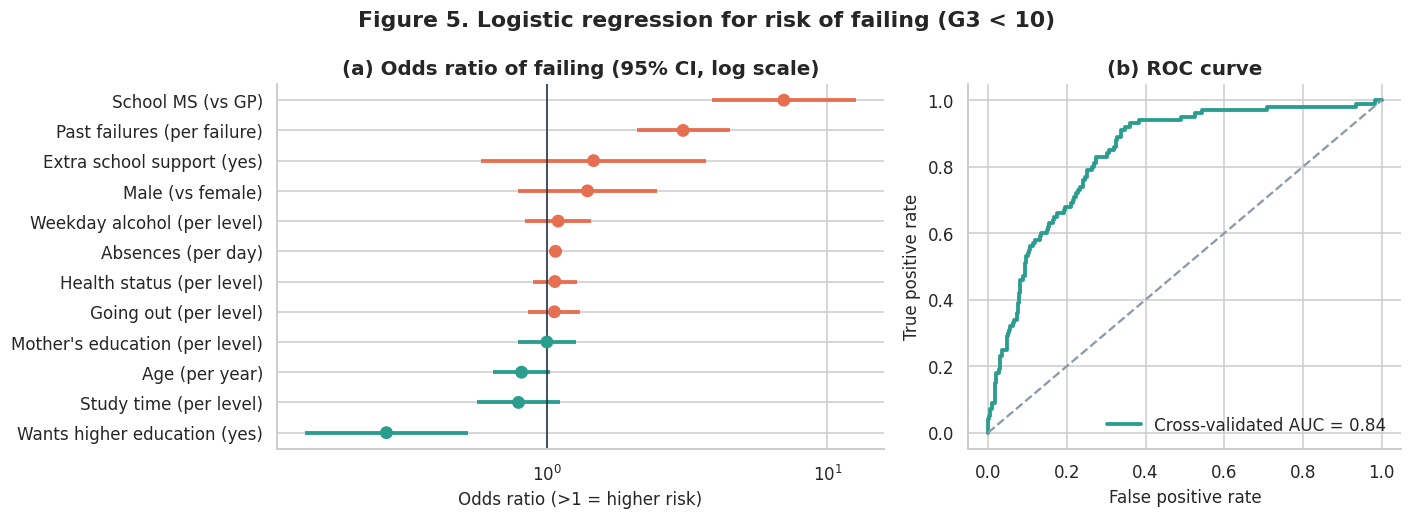

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
o = or2.drop("Intercept").sort_values("OR")
col = [CORAL if v > 1 else TEAL for v in o.OR]
ax[0].hlines(o.index, o.ci_low, o.ci_high, color=col, lw=2.5); ax[0].scatter(o.OR, o.index, color=col, s=55, zorder=3)
ax[0].axvline(1, color=NAVY, lw=1); ax[0].set_xscale("log")
ax[0].set(title="(a) Odds ratio of failing (95% CI, log scale)", xlabel="Odds ratio (>1 = higher risk)")
fpr, tpr, _ = roc_curve(df.fail, oof)
ax[1].plot(fpr, tpr, color=TEAL, lw=2.5, label=f"Cross-validated AUC = {auc:.2f}"); ax[1].plot([0, 1], [0, 1], ls="--", color=GREY)
ax[1].set(title="(b) ROC curve", xlabel="False positive rate", ylabel="True positive rate"); ax[1].legend(frameon=False, loc="lower right")
fig.suptitle("Figure 5. Logistic regression for risk of failing (G3 < 10)", fontweight="bold"); save(fig, "fig5_logistic")

## 5. RQ3 – How much do early grades add?
Nested OLS models on the same sample (n = 634):
* **M1** background factors only (RQ1 model)
* **M3a** background + `G1` (first-period grade)
* **M3b** `G1` + `G2` only (for reference)

In [23]:
formula3a = formula1 + " + G1"
formula3b = "G3 ~ G1 + G2"
m3a = smf.ols(formula3a, data=df_lin).fit(cov_type="HC3")
m3b = smf.ols(formula3b, data=df_lin).fit(cov_type="HC3")
# nested F-test (M1 vs M3a) using classical fits
f_test = smf.ols(formula3a, data=df_lin).fit().compare_f_test(m1_ols)
print(f"Nested F-test adding G1: F = {f_test[0]:.1f}, p = {f_test[1]:.2g}")
print(f"G1 coefficient = {m3a.params['G1']:.3f} (95% CI {m3a.conf_int().loc['G1',0]:.3f} to {m3a.conf_int().loc['G1',1]:.3f})")
cmp = pd.DataFrame({
    "Model": ["M1: background only", "M3a: background + G1", "M3b: G1 + G2"],
    "Adj R2": [m1.rsquared_adj, m3a.rsquared_adj, m3b.rsquared_adj],
    "CV R2": [cv_r2_1, cv_ols(formula3a, df_lin)[0], cv_ols(formula3b, df_lin)[0]],
    "CV MAE": [cv_mae_1, cv_ols(formula3a, df_lin)[1], cv_ols(formula3b, df_lin)[1]],
    "AIC": [m1.aic, m3a.aic, m3b.aic]}).round(3)
cmp

Nested F-test adding G1: F = 1207.9, p = 1.1e-147
G1 coefficient = 0.799 (95% CI 0.727 to 0.872)


,Model,Adj R2,CV R2,CV MAE,AIC
0,M1: background only,0.343,0.321,1.749,2801.498
1,M3a: background + G1,0.777,0.769,0.957,2117.999
2,M3b: G1 + G2,0.880,0.882,0.674,1712.985


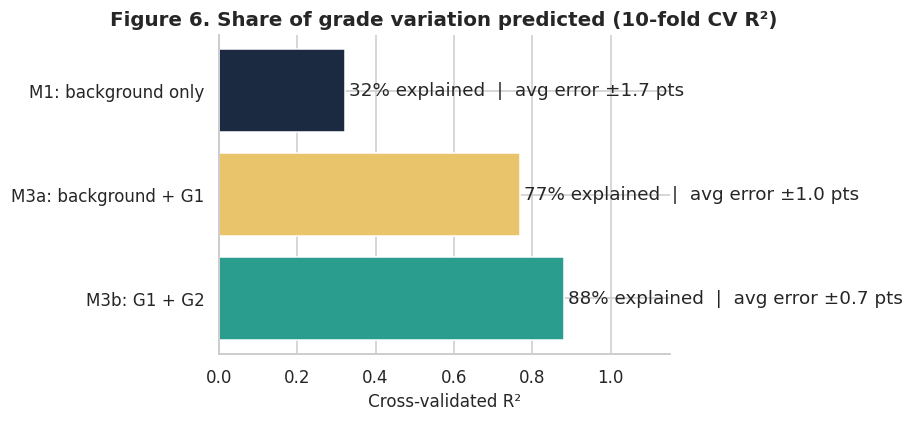

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cmp.Model[::-1], cmp["CV R2"][::-1], color=[NAVY, SAND, TEAL][::-1])
for b, v, m in zip(bars, cmp["CV R2"][::-1], cmp["CV MAE"][::-1]):
    ax.text(v + .01, b.get_y() + b.get_height()/2, f"{v:.0%} explained  |  avg error ±{m:.1f} pts", va="center")
ax.set(xlim=(0, 1.15), title="Figure 6. Share of grade variation predicted (10-fold CV R²)", xlabel="Cross-validated R²")
save(fig, "fig6_model_comparison")

M3a Breusch-Pagan p = 0.0068, residual skew = -0.12


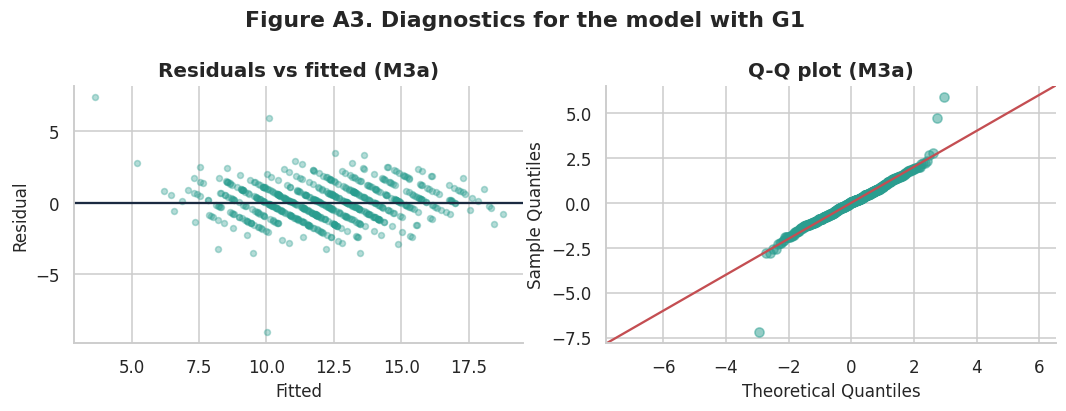

In [25]:
# M3a diagnostics (appendix)
r3 = m3a.resid
print(f"M3a Breusch-Pagan p = {het_breuschpagan(r3, m3a.model.exog)[1]:.4f}, residual skew = {stats.skew(r3):.2f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].scatter(m3a.fittedvalues, r3, alpha=.35, s=15, color=TEAL); ax[0].axhline(0, color=NAVY)
ax[0].set(title="Residuals vs fitted (M3a)", xlabel="Fitted", ylabel="Residual")
sm.qqplot(r3, line="45", fit=True, ax=ax[1], markerfacecolor=TEAL, markeredgecolor=TEAL, alpha=.5); ax[1].set_title("Q-Q plot (M3a)")
fig.suptitle("Figure A3. Diagnostics for the model with G1", fontweight="bold"); save(fig, "figA3_diag_m3a")

## 6. Summary table of key numbers (used in report & slides)

In [26]:
summary = {
    "n_total": len(df), "n_linear": len(df_lin), "n_g3_zero": int((df.G3 == 0).sum()),
    "fail_rate": round(df.fail.mean(), 3), "mean_G3": round(df_lin.G3.mean(), 2), "sd_G3": round(df_lin.G3.std(), 2),
    "m1_r2": round(m1.rsquared, 3), "m1_adj_r2": round(m1.rsquared_adj, 3), "m1_cv_r2": round(cv_r2_1, 3), "m1_cv_mae": round(cv_mae_1, 2),
    "bp_p": round(bp[1], 4), "max_vif": float(vif.max()), "auc": round(auc, 3), "pseudo_r2": round(m2.prsquared, 3),
    "m3a_adj_r2": round(m3a.rsquared_adj, 3), "m3b_adj_r2": round(m3b.rsquared_adj, 3)}
pd.Series(summary)

n_total       649.0000
n_linear      634.0000
n_g3_zero      15.0000
fail_rate       0.1540
mean_G3        12.1900
sd_G3           2.6900
m1_r2           0.3550
m1_adj_r2       0.3430
m1_cv_r2        0.3210
m1_cv_mae       1.7500
bp_p            0.0605
max_vif         1.2300
auc             0.8390
pseudo_r2       0.2700
m3a_adj_r2      0.7770
m3b_adj_r2      0.8800
dtype: float64

## References
* Cortez, P., & Silva, A. (2008). Using data mining to predict secondary school student performance. In *Proceedings of 5th FUture BUsiness TEChnology Conference (FUBUTEC 2008)* (pp. 5–12). EUROSIS.
* Data-Science Sean. (2019). *Student Performance Data Set* [Data set]. Kaggle. https://www.kaggle.com/datasets/larsen0966/student-performance-data-set
* Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. *Proc. 9th Python in Science Conference.*